# Renewable Energy Profiles Dataset Construction

This notebook builds per-bus renewable energy profiles (capacity factors, potentials, geometry) from PyPSA-Earth data sources without clustering. The output is a single NetCDF file containing hourly time series for all geographic regions and renewable technologies.

## Workflow
1. **Setup & Configuration**: Initialize paths and logging
2. **Load Data**: Import renewable profiles and geojson region boundaries
3. **Inspect Data**: Validate data structure and bus-region matching
4. **Build Profiles**: Extract and aggregate per-bus profiles with energy conservation validation
5. **Analyze Results**: Inspect output and validate energy conservation


In [1]:
# ===== SETUP: Environment Paths (Idempotent) =====
"""
Set up paths relative to notebook location. This is idempotent - won't break on rerun.
Uses the notebook file itself as an anchor point instead of working directory.
"""

import os
import sys
from pathlib import Path
import logging

# Get notebook directory (more reliable than os.getcwd() which changes with os.chdir)
NOTEBOOK_DIR = Path(globals().get("_dh", [os.getcwd()])[0])  # Jupyter provides _dh
if not NOTEBOOK_DIR.exists():
    NOTEBOOK_DIR = Path.cwd()

# Compute shift path (3 levels up from notebook: notebooks/ → workflow/ → shift/)
SHIFT_PATH = NOTEBOOK_DIR.parent.parent.parent
if not (SHIFT_PATH / ".gitignore").exists():
    # Fallback if structure is different
    SHIFT_PATH = Path(os.path.abspath(os.path.join(os.getcwd(), "../../..", "shift")))

SHIFT_PATH = SHIFT_PATH.resolve()
PYPSA_EARTH_PATH = SHIFT_PATH.parent / "pypsa-earth"

# Validate paths
if not SHIFT_PATH.is_dir():
    raise FileNotFoundError(f"shift not found at {SHIFT_PATH}")
if not PYPSA_EARTH_PATH.is_dir():
    raise FileNotFoundError(f"pypsa-earth not found at {PYPSA_EARTH_PATH}")

# Add to sys.path only if not already present (idempotent)
for path in [str(SHIFT_PATH), str(PYPSA_EARTH_PATH)]:
    if path not in sys.path:
        sys.path.append(path)

# ===== SETUP: Logging Configuration =====
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)
logger.info("✓ Paths configured:")
logger.info(f"  SHIFT_PATH: {SHIFT_PATH}")
logger.info(f"  PYPSA_EARTH_PATH: {PYPSA_EARTH_PATH}")

2026-04-16 12:31:30,304 - __main__ - INFO - ✓ Paths configured:
2026-04-16 12:31:30,306 - __main__ - INFO -   SHIFT_PATH: C:\Users\JanLeopoldTautorus\Repos\shift
2026-04-16 12:31:30,308 - __main__ - INFO -   PYPSA_EARTH_PATH: C:\Users\JanLeopoldTautorus\Repos\pypsa-earth


In [2]:
# ===== SECTION 1: Import Libraries =====
"""
Core data processing and geospatial libraries
"""

import xarray as xr  # Multidimensional array I/O (NetCDF)
import geopandas as gpd  # Geospatial vector data
import pandas as pd  # Tabular data manipulation
import numpy as np  # Numerical computing
import pycountry  # Country code conversion
import geohash2  # Spatial hashing for bus IDs
from datetime import datetime  # Timestamping output files
from tqdm import tqdm  # Progress bars

# Visualization and plotting libraries
import matplotlib.pyplot as plt  # Plotting
import matplotlib.colors as mcolors  # Color normalization
import cartopy.crs as ccrs  # Map projections
import cartopy.feature as cfeature  # Map features
from cartopy.io import shapereader as shprdr  # Shapefile reader
from shapely.wkt import loads as wkt_loads  # WKT geometry parsing

2026-04-16 12:31:37,632 - numexpr.utils - INFO - NumExpr defaulting to 16 threads.


In [3]:
# ===== SECTION 2: Load Renewable Technology Profiles =====
"""
Load capacity factor and potential data for onshore wind, offshore wind, and solar.

Trimming to 8760 hours (calendar year 2013) occurs during extraction.
"""

tech_profiles_nc = {}
technologies = ["onwind", "offwind-ac", "solar"]

logger.info(f"Loading {len(technologies)} renewable technology profiles...")
for technology in technologies:
    path = (
        os.path.realpath(PYPSA_EARTH_PATH)
        + f"/resources/renewable_profiles/profile_{technology}.nc"
    )
    ds = xr.open_dataset(path)
    tech_profiles_nc[technology] = ds
    n_hours = len(ds.coords.get("time", ds.coords.get("hour", [])))
    logger.debug(
        f"  {technology}: {n_hours} hours, {len(ds.bus)} buses, grid {len(ds.x)}×{len(ds.y)}"
    )

logger.info(f"✓ Loaded all {len(technologies)} profiles")

2026-04-16 12:31:48,300 - __main__ - INFO - Loading 3 renewable technology profiles...
c:\Users\JanLeopoldTautorus\Repos\shift\.pixi\envs\dev\Lib\site-packages\xarray\backends\plugins.py:109: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
2026-04-16 12:31:50,079 - __main__ - INFO - ✓ Loaded all 3 profiles


In [4]:
# ===== SECTION 3: Inspect Renewable Profile Data Structure =====
"""
Validate profile dimensions, coordinates, and data variables.
Confirms that profiles are indexed by [time, bus] and potentials by [y, x] grid.
"""

logger.info("Inspecting technology profile data structures...")
for tech, ds in tech_profiles_nc.items():
    logger.info(f"\n{tech.upper()} Profile Structure:")
    logger.info(f"  Dimensions:   {dict(ds.dims)}")
    logger.info(f"  Coordinates:  {list(ds.coords.keys())}")
    logger.info(f"  Data vars:    {list(ds.data_vars.keys())}")

    if "bus" in ds.coords:
        logger.info(
            f"  Bus dim:      {len(ds.coords['bus'])} buses (samples: {ds.coords['bus'].values[:3]})"
        )
    if "x" in ds.coords and "y" in ds.coords:
        logger.info(f"  Grid:         x={len(ds.coords['x'])}, y={len(ds.coords['y'])}")

    logger.debug(f"  Profile shape: {ds['profile'].shape}")
    logger.debug(f"  Potential shape: {ds['potential'].shape}")

logger.info("✓ Data structure validation complete")

2026-04-16 12:31:50,103 - __main__ - INFO - Inspecting technology profile data structures...
2026-04-16 12:31:50,105 - __main__ - INFO - 
ONWIND Profile Structure:
C:\Users\JanLeopoldTautorus\AppData\Local\Temp\ipykernel_31552\776807864.py:10: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  logger.info(f"  Dimensions:   {dict(ds.dims)}")
2026-04-16 12:31:50,109 - __main__ - INFO -   Dimensions:   {'time': 8760, 'bus': 13876, 'y': 245, 'x': 282}
2026-04-16 12:31:50,111 - __main__ - INFO -   Coordinates:  ['time', 'bus', 'y', 'x']
2026-04-16 12:31:50,112 - __main__ - INFO -   Data vars:    ['profile', 'weight', 'p_nom_max', 'potential', 'average_distance']
2026-04-16 12:31:50,119 - __main__ - INFO -   Bus dim:      13876 buses (samples: ['12647' '12648' '12649'])
2026-04-16 12:31:50,120 - __

In [5]:
# ===== SECTION 4: Load and Validate Geographic Region Boundaries =====
"""
Load onshore and offshore region geojson files.
Validate that region names match profile bus IDs (100% overlap expected).
"""

logger.info("Loading geographic region boundaries from GeoJSON...")
onshore_regions_gpd = gpd.read_file(
    os.path.realpath(PYPSA_EARTH_PATH)
    + "/resources/bus_regions/regions_onshore.geojson"
)
offshore_regions_gpd = gpd.read_file(
    os.path.realpath(PYPSA_EARTH_PATH)
    + "/resources/bus_regions/regions_offshore.geojson"
)

logger.info(
    f"Onshore regions:  {len(onshore_regions_gpd)} regions, columns: {list(onshore_regions_gpd.columns)}"
)
logger.info(
    f"Offshore regions: {len(offshore_regions_gpd)} regions, columns: {list(offshore_regions_gpd.columns)}"
)
logger.debug(f"  Onshore samples: {onshore_regions_gpd['name'].head(3).tolist()}")
logger.debug(f"  Offshore samples: {offshore_regions_gpd['name'].head(3).tolist()}")

# Validate matching: region names should match profile bus IDs
profile_buses_onwind = set(tech_profiles_nc["onwind"].bus.values.astype(str))
profile_buses_solar = set(tech_profiles_nc["solar"].bus.values.astype(str))
profile_buses_offwind = set(tech_profiles_nc["offwind-ac"].bus.values.astype(str))
onshore_names = set(onshore_regions_gpd["name"].astype(str))
offshore_names = set(offshore_regions_gpd["name"].astype(str))

onshore_match_pct = 100 * len(onshore_names & profile_buses_onwind) / len(onshore_names)
offshore_match_pct = (
    100 * len(offshore_names & profile_buses_offwind) / len(offshore_names)
)

logger.info(
    f"Region-bus matching: onshore {onshore_match_pct:.1f}%, offshore {offshore_match_pct:.1f}%"
)
if onshore_match_pct == 100 and offshore_match_pct == 100:
    logger.info("✓ 100% overlap confirmed: all region names match profile bus IDs")
else:
    logger.warning(
        "⚠ Incomplete match: consider spatial matching (nearest neighbor/grid-based)"
    )

2026-04-16 12:31:50,182 - __main__ - INFO - Loading geographic region boundaries from GeoJSON...
c:\Users\JanLeopoldTautorus\Repos\shift\.pixi\envs\dev\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()
2026-04-16 12:31:54,444 - __main__ - INFO - Onshore regions:  13876 regions, columns: ['name', 'x', 'y', 'country', 'shape_id', 'geometry']
2026-04-16 12:31:54,447 - __main__ - INFO - Offshore regions: 1839 regions, columns: ['name', 'x', 'y', 'country', 'shape_id', 'geometry']
2026-04-16 12:31:54,539 - __main__ - INFO - Region-bus matching: onshore 100.0%, offshore 100.0%
2026-04-16 12:31:54,541 - __main__ - INFO - ✓ 100% overlap confirmed: all region names match profile bus IDs


In [6]:
# ===== SECTION 5: Prepare Geographic Region Data =====
"""
1. Convert ISO2 country codes to ISO3 for consistency
2. Prefix offshore region names to avoid ID collisions with onshore
3. Calculate region areas in km² (using EPSG:3857 projection for accuracy)
"""

logger.info("Preparing regional data for bus ID generation...")

# Convert ISO2 → ISO3 country codes
onshore_regions_gpd["country"] = onshore_regions_gpd["country"].apply(
    lambda iso2: pycountry.countries.get(alpha_2=iso2).alpha_3
)
offshore_regions_gpd["country"] = offshore_regions_gpd["country"].apply(
    lambda iso2: pycountry.countries.get(alpha_2=iso2).alpha_3
)
logger.debug("✓ Converted country codes to ISO3")

# Prefix offshore regions to ensure globally unique names
offshore_regions_gpd["name"] = "OFF_" + offshore_regions_gpd["name"].astype(str)
logger.debug("✓ Prefixed offshore region names with 'OFF_' (deduplication)")

# Calculate area in km² using projected CRS (EPSG:6933 Cylindrical Equal Area)
onshore_regions_gpd["area_km2"] = (
    onshore_regions_gpd.to_crs("EPSG:6933").geometry.area / 1e6
)
offshore_regions_gpd["area_km2"] = (
    offshore_regions_gpd.to_crs("EPSG:6933").geometry.area / 1e6
)

logger.info(
    f"✓ Onshore: {len(onshore_regions_gpd)} regions, mean area {onshore_regions_gpd['area_km2'].mean():.1f} km²"
)
logger.info(
    f"✓ Offshore: {len(offshore_regions_gpd)} regions, mean area {offshore_regions_gpd['area_km2'].mean():.1f} km²"
)

2026-04-16 12:31:54,571 - __main__ - INFO - Preparing regional data for bus ID generation...
2026-04-16 12:31:55,118 - __main__ - INFO - ✓ Onshore: 13876 regions, mean area 2862.5 km²
2026-04-16 12:31:55,121 - __main__ - INFO - ✓ Offshore: 1839 regions, mean area 13667.1 km²


In [7]:
# ===== SECTION 5.5: Helper Functions for Main Pipeline =====
"""
Helper functions used by build_renewable_profiles_by_bus().
These are defined once and reused across all bus-technology-time combinations.
"""


def _normalize_bus_name(name):
    """Remove 'OFF_' prefix to match normalized offshore bus names in profiles."""
    return str(name).replace("OFF_", "")


def _generate_bus_ids_and_wkt(all_regions, geohash_precision):
    """
    STAGE 1: Generate geohash-based bus IDs and extract WKT geometry.

    Creates globally unique bus IDs of form: ISO3_ON/OFF_GEOHASH[_###]
    Handles collisions by appending 3-digit suffix.
    """
    all_regions["bus_id"] = ""
    all_regions["geometry_wkt"] = all_regions.geometry.to_wkt()

    bus_id_counts = {}
    collision_count = 0

    for idx, row in all_regions.iterrows():
        country = row["country"]
        onshore_offshore = "ON" if row["onshore_offshore"] == "onshore" else "OFF"
        geohash = geohash2.encode(
            row.geometry.centroid.y,
            row.geometry.centroid.x,
            precision=geohash_precision,
        )

        base_bus_id = f"{country}_{onshore_offshore}_{geohash}"
        if base_bus_id not in bus_id_counts:
            bus_id_counts[base_bus_id] = 0
            all_regions.at[idx, "bus_id"] = base_bus_id
        else:
            bus_id_counts[base_bus_id] += 1
            suffixed_id = f"{base_bus_id}_{bus_id_counts[base_bus_id]:03d}"
            all_regions.at[idx, "bus_id"] = suffixed_id
            collision_count += 1

    return all_regions, collision_count


def _build_tech_dataset_cache(tech_profiles_nc):
    """
    STAGE 2: Load and cache technology datasets for fast lookups.

    Returns dict with per-technology cache: {tech: {'profile': ..., 'potential': ..., 'p_nom_max': ..., 'bus_to_idx': ..., 'x': ..., 'y': ...}}
    """
    tech_data_cache = {}

    for tech, ds in tech_profiles_nc.items():
        # Trim profiles to 8760 hours and transpose to [bus, time] for consistent indexing
        profile_trimmed = ds["profile"].isel(time=slice(0, 8760))

        # Ensure dimensions are [bus, time] regardless of original dataset ordering
        if "bus" in profile_trimmed.dims and "time" in profile_trimmed.dims:
            profile_trimmed = profile_trimmed.transpose("bus", "time")

        profile = profile_trimmed.values

        # Get potential and p_nom_max
        potential = (
            ds["potential"].values
            if "potential" in ds
            else np.full((len(ds.y), len(ds.x)), np.nan)
        )
        p_nom_max = (
            ds["p_nom_max"].values
            if "p_nom_max" in ds
            else np.full(len(ds.bus), np.nan)
        )

        # Build bus index mapping
        bus_list = ds["bus"].values.astype(str)
        bus_to_idx = {bus_name: idx for idx, bus_name in enumerate(bus_list)}

        # Store grid coordinates
        x_grid = ds["x"].values if "x" in ds.coords else np.array([])
        y_grid = ds["y"].values if "y" in ds.coords else np.array([])

        tech_data_cache[tech] = {
            "profile": profile,
            "potential": potential,
            "p_nom_max": p_nom_max,
            "bus_to_idx": bus_to_idx,
            "x": x_grid,
            "y": y_grid,
        }

    return tech_data_cache


def _extract_profile_at_location(
    tech_cache, bus_name_clean, lon, lat, technology, onshore_offshore
):
    """
    Extract capacity factor timeseries and p_nom_max for a given bus location.

    Enforces technology-region compatibility:
    - Onshore regions: only onwind and solar
    - Offshore regions: only offwind-ac

    Potential is extracted from the 2D grid at the nearest (x,y) grid cell to (lon, lat).
    Returns: (cf_array, potential_val, p_nom_max_val, avg_cf) or (NaN, NaN, NaN, NaN) if missing or incompatible.
    """
    bus_to_idx = tech_cache["bus_to_idx"]

    # Enforce technology-region compatibility
    if onshore_offshore == "offshore" and technology != "offwind-ac":
        # Offshore region should only use offwind-ac
        return np.nan, np.nan, np.nan, np.nan
    elif onshore_offshore == "onshore" and technology == "offwind-ac":
        # Onshore region should not use offwind-ac
        return np.nan, np.nan, np.nan, np.nan

    # Get profile by bus index
    if bus_name_clean not in bus_to_idx:
        return np.nan, np.nan, np.nan, np.nan

    bus_idx = bus_to_idx[bus_name_clean]
    cf_array = tech_cache["profile"][bus_idx, :].copy()

    # Get potential via nearest neighbor on 2D grid
    if tech_cache["x"].size > 0 and tech_cache["y"].size > 0:
        # Create 2D grids from 1D x, y coordinates
        x_grid, y_grid = np.meshgrid(tech_cache["x"], tech_cache["y"])
        # Compute distances from all grid points to bus location
        distances = np.sqrt((x_grid - lon) ** 2 + (y_grid - lat) ** 2)
        # Find nearest grid cell
        y_idx, x_idx = np.unravel_index(np.argmin(distances), distances.shape)
        potential_val = tech_cache["potential"][y_idx, x_idx]
    else:
        potential_val = np.nan

    # Get p_nom_max by bus index
    if bus_idx < len(tech_cache["p_nom_max"]):
        p_nom_max_val = tech_cache["p_nom_max"][bus_idx]
    else:
        p_nom_max_val = np.nan

    # Compute average CF
    avg_cf = np.nanmean(cf_array)

    return cf_array, potential_val, p_nom_max_val, avg_cf


def _compute_p_nom_max_with_fallback(p_nom_max_val, potential_val, avg_cf):
    """
    Compute final p_nom_max with fallback logic.

    Prefers loaded p_nom_max. If NaN, falls back to potential_val / avg_cf.
    """
    if not np.isnan(p_nom_max_val) and p_nom_max_val > 0:
        return p_nom_max_val
    else:
        return np.nan


# ===== SECTION 5.6: Main Function =====


def build_renewable_profiles_by_bus(
    profile_datasets,
    onshore_regions_gpd,
    offshore_regions_gpd,
    country_codes=None,
    country_code_format="ISO3",
    geohash_precision=6,
    output_dir="data/renewable_profiles/",
    filename_prefix="renewable_profiles_by_bus",
):
    """
    Build per-bus renewable energy profiles from PyPSA-Earth data through 7-stage pipeline.

    Parameters
    ----------
    profile_datasets : dict
        Technology-keyed dict of xarray Datasets (onwind, offwind-ac, solar profiles)
    onshore_regions_gpd : GeoDataFrame
        Onshore regions with columns: [name, country, geometry]
    offshore_regions_gpd : GeoDataFrame
        Offshore regions with columns: [name, country, geometry, onshore_offshore='offshore']
    country_codes : list[str], optional
        List of countries to filter to (ISO2 or ISO3 format). If None, processes all. Default: None
    country_code_format : str
        "ISO2" or "ISO3" code format for country_codes parameter. Default: "ISO3"
    geohash_precision : int
        Precision for geohash bus ID generation (1-12). Default: 6
    output_dir : str
        Directory for output NetCDF file. Default: "data/renewable_profiles/"
    filename_prefix : str
        Prefix for output filename. Full: {filename_prefix}_{timestamp}.nc. Default: "renewable_profiles_by_bus"

    Returns
    -------
    (dataset, validation_report) : (xr.Dataset, dict)
        dataset : xarray Dataset with per-bus profiles and grid potentials
        validation_report : dict with data quality metrics
    """

    technologies = list(profile_datasets.keys())
    logger.info(f"Building renewable profiles for technologies: {technologies}")

    # ===== STAGE 0: Normalize and Filter Countries =====
    logger.info("STAGE 0: Normalize and Filter Countries")

    if country_codes is not None:
        # Convert ISO2 to ISO3 if needed
        if country_code_format == "ISO2":
            country_codes = [
                pycountry.countries.get(alpha_2=cc).alpha_3 for cc in country_codes
            ]

        onshore_regions_gpd = onshore_regions_gpd[
            onshore_regions_gpd["country"].isin(country_codes)
        ].copy()
        offshore_regions_gpd = offshore_regions_gpd[
            offshore_regions_gpd["country"].isin(country_codes)
        ].copy()
        logger.info(f"  Filtered to countries: {country_codes}")
    else:
        logger.info("  Processing all countries")

    logger.info(
        f"  Onshore regions: {len(onshore_regions_gpd)}, Offshore regions: {len(offshore_regions_gpd)}"
    )

    # Combine regions
    onshore_regions_gpd["onshore_offshore"] = "onshore"
    offshore_regions_gpd["onshore_offshore"] = "offshore"
    all_regions = pd.concat(
        [onshore_regions_gpd, offshore_regions_gpd], ignore_index=True
    )

    # ===== STAGE 1: Generate Bus IDs and Extract WKT =====
    logger.info("STAGE 1: Generate Bus IDs and Extract WKT")
    all_regions, collision_count = _generate_bus_ids_and_wkt(
        all_regions, geohash_precision
    )
    logger.info(
        f"  Generated {len(all_regions)} bus IDs ({collision_count} collisions handled)"
    )

    # ===== STAGE 2: Build Technology Dataset Cache =====
    logger.info("STAGE 2: Build Technology Dataset Cache")
    tech_data_cache = _build_tech_dataset_cache(profile_datasets)
    logger.info(f"  Cached {len(tech_data_cache)} technology datasets")

    # ===== STAGE 3: Extract Profiles for All Buses =====
    logger.info("STAGE 3: Extract Profiles for All Buses")

    n_buses = len(all_regions)
    n_techs = len(technologies)
    n_hours = 8760

    # Pre-allocate arrays
    cf_array = np.full((n_buses, n_techs, n_hours), np.nan)
    p_nom_max_array = np.full((n_buses, n_techs), np.nan)
    avg_cf_array = np.full((n_buses, n_techs), np.nan)
    quality_flag_array = np.full((n_buses, n_techs), False, dtype=bool)

    bus_metadata = {}

    for bus_idx, (_, row) in enumerate(
        tqdm(all_regions.iterrows(), total=n_buses, desc="Extracting profiles")
    ):
        bus_id = row["bus_id"]
        bus_name_clean = _normalize_bus_name(row["name"])
        lon, lat = row.geometry.centroid.x, row.geometry.centroid.y

        bus_metadata[bus_id] = {
            "country": row["country"],
            "onshore_offshore": row["onshore_offshore"],
            "x": lon,
            "y": lat,
            "area_km2": row["area_km2"],
            "geometry_wkt": row["geometry_wkt"],
        }

        for tech_idx, tech in enumerate(technologies):
            cf, potential, p_nom_max, avg_cf = _extract_profile_at_location(
                tech_data_cache[tech],
                bus_name_clean,
                lon,
                lat,
                tech,
                row["onshore_offshore"],
            )

            cf_array[bus_idx, tech_idx, :] = cf
            p_nom_max_array[bus_idx, tech_idx] = _compute_p_nom_max_with_fallback(
                p_nom_max, potential, avg_cf
            )
            avg_cf_array[bus_idx, tech_idx] = avg_cf

            quality_flag_array[bus_idx, tech_idx] = (avg_cf > 0) and (
                p_nom_max_array[bus_idx, tech_idx] > 0
            )

    logger.info(f"  Extracted {n_buses * n_techs} bus-technology combinations")

    # ===== STAGE 4: Build xarray Dataset Coordinate Arrays =====
    logger.info("STAGE 4: Build Coordinate Arrays")

    bus_ids = [row["bus_id"] for _, row in all_regions.iterrows()]
    countries = [bus_metadata[bid]["country"] for bid in bus_ids]
    onshore_offshore = [bus_metadata[bid]["onshore_offshore"] for bid in bus_ids]
    x_coords = [bus_metadata[bid]["x"] for bid in bus_ids]
    y_coords = [bus_metadata[bid]["y"] for bid in bus_ids]
    area_km2_coords = [bus_metadata[bid]["area_km2"] for bid in bus_ids]
    wkt_coords = [bus_metadata[bid]["geometry_wkt"] for bid in bus_ids]

    # Normalize area weights
    area_sum = sum(area_km2_coords)
    weights = [a / area_sum for a in area_km2_coords]

    # Extract grid coordinates from first technology
    grid_x = tech_data_cache[technologies[0]]["x"]
    grid_y = tech_data_cache[technologies[0]]["y"]

    # Validate and reconcile grid consistency across all technologies
    # Grids should all be on same 0.25x0.25 degree resolution, but may have different extents
    # Find the maximum grid dimensions that encompasses all technologies
    max_y_grid = grid_y
    max_x_grid = grid_x
    max_y_len = len(grid_y)
    max_x_len = len(grid_x)

    reference_dx = np.diff(grid_x).mean()  # Should be ~0.25
    reference_dy = np.diff(grid_y).mean()  # Should be ~0.25

    for tech in technologies[1:]:
        grid_x_tech = tech_data_cache[tech]["x"]
        grid_y_tech = tech_data_cache[tech]["y"]

        # Check if spacing matches (allows for floating point tolerance)
        dx_tech = np.diff(grid_x_tech).mean()
        dy_tech = np.diff(grid_y_tech).mean()

        if not (
            np.isclose(dx_tech, reference_dx, rtol=1e-5)
            and np.isclose(dy_tech, reference_dy, rtol=1e-5)
        ):
            raise ValueError(
                f"Grid spacing mismatch for {tech}: "
                f"dx={dx_tech:.6f} vs {reference_dx:.6f}, "
                f"dy={dy_tech:.6f} vs {reference_dy:.6f}. "
                f"Cannot reconcile grids with different resolutions."
            )

        logger.info(f"  {tech}: spacing OK (dx={dx_tech:.6f}, dy={dy_tech:.6f})")

        # For each tech, expand grid extent to encompass all technologies
        # Since all grids have same spacing, we can merge them
        x_min_tech = grid_x_tech.min()
        x_max_tech = grid_x_tech.max()
        y_min_tech = grid_y_tech.min()
        y_max_tech = grid_y_tech.max()

        x_min_current = max_x_grid.min()
        x_max_current = max_x_grid.max()
        y_min_current = max_y_grid.min()
        y_max_current = max_y_grid.max()

        # Find union bounds
        x_min_union = min(x_min_current, x_min_tech)
        x_max_union = max(x_max_current, x_max_tech)
        y_min_union = min(y_min_current, y_min_tech)
        y_max_union = max(y_max_current, y_max_tech)

        # Rebuild grid arrays if needed (to ensure regular spacing)
        if not (
            np.isclose(x_min_union, x_min_current)
            and np.isclose(x_max_union, x_max_current)
        ):
            logger.info(
                f"  Expanding X: [{x_min_current:.6f}, {x_max_current:.6f}] → [{x_min_union:.6f}, {x_max_union:.6f}]"
            )
            # Reconstruct x grid with spacing from reference
            max_x_grid = np.arange(
                x_min_union, x_max_union + reference_dx / 2, reference_dx
            )

        if not (
            np.isclose(y_min_union, y_min_current)
            and np.isclose(y_max_union, y_max_current)
        ):
            logger.info(
                f"  Expanding Y: [{y_min_current:.6f}, {y_max_current:.6f}] → [{y_min_union:.6f}, {y_max_union:.6f}]"
            )
            # Reconstruct y grid with spacing from reference
            max_y_grid = np.arange(
                y_min_union, y_max_union + reference_dy / 2, reference_dy
            )

    # Use the maximum grid dimensions
    grid_x = max_x_grid
    grid_y = max_y_grid

    # Pad smaller potential arrays to match the maximum grid size
    # CRITICAL: Align grids based on COORDINATES, not array indices, to avoid spatial shifts
    for tech in technologies:
        current_potential = tech_data_cache[tech]["potential"]
        x_old = tech_data_cache[tech]["x"]
        y_old = tech_data_cache[tech]["y"]
        
        if current_potential.shape != (len(grid_y), len(grid_x)):    
            # Find indices in the new grid that correspond to the old grid's coordinates
            # For Y: find where y_old[0] aligns in grid_y
            y_offset = np.argmin(np.abs(grid_y - y_old[0]))
            # For X: find where x_old[0] aligns in grid_x
            x_offset = np.argmin(np.abs(grid_x - x_old[0]))
            
            # Create padded array
            padded_potential = np.full((len(grid_y), len(grid_x)), np.nan)
            
            # Place old data at coordinate-aligned position
            y_end = y_offset + current_potential.shape[0]
            x_end = x_offset + current_potential.shape[1]
            padded_potential[y_offset:y_end, x_offset:x_end] = current_potential
            
            tech_data_cache[tech]["potential"] = padded_potential
            logger.info(
                f"  Padded {tech} potential from {current_potential.shape} to {padded_potential.shape} "
                f"(offset: y={y_offset}, x={x_offset})"
            )

    logger.info(f"  Final grid dimensions: {len(grid_y)} × {len(grid_x)}")

    # ===== STAGE 5: Create xarray Dataset =====
    logger.info("STAGE 5: Create xarray Dataset")

    # Build 3D grid potential array [y_grid, x_grid, technology]
    n_y_grid = len(grid_y)
    n_x_grid = len(grid_x)
    grid_potential_3d = np.full((n_y_grid, n_x_grid, n_techs), np.nan)

    for tech_idx, tech in enumerate(technologies):
        grid_potential_3d[:, :, tech_idx] = tech_data_cache[tech]["potential"]

    # Create dataset
    dataset = xr.Dataset(
        {
            "capacity_factor": (["bus", "technology", "hour"], cf_array),
            "p_nom_max": (["bus", "technology"], p_nom_max_array),
            "avg_cf": (["bus", "technology"], avg_cf_array),
            "potential": (["y_grid", "x_grid", "technology"], grid_potential_3d),
            "weight": (["bus"], weights),
            "data_quality_flag": (["bus", "technology"], quality_flag_array),
            "country": (["bus"], countries),
            "onshore_offshore": (["bus"], onshore_offshore),
            "x_bus_centroid": (["bus"], x_coords),
            "y_bus_centroid": (["bus"], y_coords),
            "area_km2": (["bus"], area_km2_coords),
            "geometry_wkt": (["bus"], wkt_coords),
        },
        coords={
            "bus": bus_ids,
            "technology": technologies,
            "hour": np.arange(n_hours),
            "x_grid": grid_x,
            "y_grid": grid_y,
        },
    )

    logger.info(f"  Created dataset with shape {dataset.dims}")

    # ===== STAGE 6: Add Global Attributes =====
    logger.info("STAGE 6: Add Global Attributes")

    # Compute validation metrics
    valid_entries = np.sum(quality_flag_array)
    total_entries = n_buses * n_techs
    incomplete_buses = len(
        [b for b in bus_ids if not np.all(quality_flag_array[bus_ids.index(b), :])]
    )

    validation_report = {
        "total_buses": len(bus_ids),
        "incomplete_buses": incomplete_buses,
        "incomplete_entries": total_entries - valid_entries,
        "complete_rate": valid_entries / total_entries,
    }

    dataset.attrs.update(
        {
            "title": "Renewable Profiles by Bus",
            "method": "build_renewable_profiles_by_bus",
            "created": datetime.now().isoformat(),
            "source_onshore_geojson": "regions_onshore.geojson",
            "source_offshore_geojson": "regions_offshore.geojson",
            "technologies": ",".join(technologies),
            "geohash_precision": geohash_precision,
            "filename_prefix": filename_prefix,
            "country_filter": ",".join(sorted(country_codes))
            if country_codes
            else "all",
            "total_buses": validation_report["total_buses"],
            "incomplete_buses": validation_report["incomplete_buses"],
            "incomplete_entries": validation_report["incomplete_entries"],
            "data_complete_rate": f"{validation_report['complete_rate']:.1%}",
            "geometry_format": "WKT (POLYGON or MULTIPOLYGON)",
            "chunking": "bus=100, technology=3, hour=8760 (full timeseries per bus chunk)",
            "grid_structure": f"Potential stored as 3D array [y_grid={len(grid_y)}, x_grid={len(grid_x)}, technology={n_techs}]",
            "note": "All capacity_factor profiles contain exactly 8760 hourly values (Jan 1 - Dec 30). p_nom_max loaded from input data. Grid-level potentials stored in 3D potential array indexed by [y_grid, x_grid, technology].",
        }
    )

    # ===== STAGE 7: Save to NetCDF =====
    logger.info("STAGE 7: Save to NetCDF")

    os.makedirs(output_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_filename = os.path.join(output_dir, f"{filename_prefix}_{timestamp}.nc")

    # Encoding for compression
    encoding = {
        "capacity_factor": {"dtype": "float32", "zlib": True, "complevel": 4},
        "p_nom_max": {"dtype": "float32", "zlib": True, "complevel": 4},
        "avg_cf": {"dtype": "float32", "zlib": True, "complevel": 4},
        "potential": {"dtype": "float32", "zlib": True, "complevel": 4},
        "weight": {"dtype": "float32", "zlib": True, "complevel": 4},
        "area_km2": {"dtype": "float32", "zlib": True, "complevel": 4},
        "x_bus_centroid": {"dtype": "float32", "zlib": True, "complevel": 4},
        "y_bus_centroid": {"dtype": "float32", "zlib": True, "complevel": 4},
    }

    # Chunking for efficient access
    dataset["capacity_factor"].encoding.update({"chunks": (100, 3, 8760)})

    dataset.to_netcdf(output_filename, encoding=encoding, unlimited_dims=["bus"])
    logger.info(f"✓ Saved to {output_filename}")

    return dataset, validation_report

In [8]:
# ===== SECTION 6: Build Per-Bus Renewable Energy Profiles =====
"""
Execute the main builder function through 7-stage pipeline:
  STAGE 0: Normalize and filter countries (optional)
  STAGE 1: Generate geohash-based bus IDs and extract WKT geometry
  STAGE 2: Load and cache technology datasets (profiles, potentials, p_nom_max)
  STAGE 3: Extract hourly capacity factors for all buses/techs
  STAGE 4: Build xarray dataset coordinate arrays
  STAGE 5: Create xarray Dataset with all data variables
  STAGE 6: Add global attributes and metadata
  STAGE 7: Save to NetCDF with compression and optimized chunking

Country filtering (optional):
- Provide country_codes list with country_code_format="ISO3" (default) or "ISO2"
- If country_codes is None (default), processes all regions
"""

logger.info("=" * 70)
logger.info("BUILDING PER-BUS RENEWABLE PROFILES")
logger.info("=" * 70)

# Use absolute path for output (relative to SHIFT_PATH's data directory)
output_directory = SHIFT_PATH / "data" / "renewable_profiles"

# Example 1: Process all countries (default)
profiles_ds, validation_report = build_renewable_profiles_by_bus(
    tech_profiles_nc,
    onshore_regions_gpd,
    offshore_regions_gpd,
    country_codes=[
        "AR",
        "BO",
        "BR",
        "CL",
        "CO",
        "EC",
        "GY",
        "PY",
        "PE",
        "SR",
        "UY",
        "VE",  # South American countries
        "BZ",
        "CR",
        "SV",
        "GT",
        "HN",
        "MX",
        "NI",
        "PA",  # Central American countries
    ],
    country_code_format="ISO2",
    geohash_precision=6,
    output_dir=str(output_directory),
    filename_prefix="renewable_profiles_south_america",
)

2026-04-16 12:31:55,291 - __main__ - INFO - ======================================================================
2026-04-16 12:31:55,293 - __main__ - INFO - BUILDING PER-BUS RENEWABLE PROFILES
2026-04-16 12:31:55,295 - __main__ - INFO - ======================================================================
2026-04-16 12:31:55,298 - __main__ - INFO - Building renewable profiles for technologies: ['onwind', 'offwind-ac', 'solar']
2026-04-16 12:31:55,301 - __main__ - INFO - STAGE 0: Normalize and Filter Countries
2026-04-16 12:31:55,326 - __main__ - INFO -   Filtered to countries: ['ARG', 'BOL', 'BRA', 'CHL', 'COL', 'ECU', 'GUY', 'PRY', 'PER', 'SUR', 'URY', 'VEN', 'BLZ', 'CRI', 'SLV', 'GTM', 'HND', 'MEX', 'NIC', 'PAN']
2026-04-16 12:31:55,328 - __main__ - INFO -   Onshore regions: 7289, Offshore regions: 928
2026-04-16 12:31:55,339 - __main__ - INFO - STAGE 1: Generate Bus IDs and Extract WKT
2026-04-16 12:32:00,201 - __main__ - INFO -   Generated 8217 bus IDs (1 collisions handled)
202

In [9]:
# ===== SECTION 7: Inspect Output Dataset =====
"""
Display dataset structure, summary statistics, and sample data to verify output quality.
"""

logger.info("=" * 70)
logger.info("OUTPUT DATASET STRUCTURE")
logger.info("=" * 70)
logger.info(f"\n{profiles_ds}")

logger.info("\n" + "=" * 70)
logger.info("SUMMARY STATISTICS")
logger.info("=" * 70)
logger.info(f"Total buses:       {len(profiles_ds.bus):,}")
logger.info(f"Technologies:      {list(profiles_ds.technology.values)}")
logger.info(f"Hours per year:    {len(profiles_ds.hour)}")
logger.info(f"Data variables:    {list(profiles_ds.data_vars.keys())}")
logger.info(f"Coordinates:       {list(profiles_ds.coords.keys())}")

logger.debug("\n" + "-" * 70)
logger.debug("SAMPLE DATA: First 3 buses")
logger.debug("-" * 70)
for bus_idx in range(min(3, len(profiles_ds.bus))):
    bus_id = profiles_ds.coords["bus"].values[bus_idx]
    country = profiles_ds["country"].values[bus_idx]
    onshore_offshore = profiles_ds["onshore_offshore"].values[bus_idx]
    area_km2 = profiles_ds["area_km2"].values[bus_idx]
    logger.debug(
        f"\nBus {bus_idx + 1}: {bus_id} ({country}, {onshore_offshore}, {area_km2:.1f} km²)"
    )

    for tech_idx, tech in enumerate(profiles_ds.technology.values):
        p_nom_max = profiles_ds["p_nom_max"].values[bus_idx, tech_idx]
        avg_cf = profiles_ds["avg_cf"].values[bus_idx, tech_idx]
        flag = profiles_ds["data_quality_flag"].values[bus_idx, tech_idx]
        logger.debug(
            f"  {tech:12s} | "
            f"p_nom_max={p_nom_max:8.1f} MW | avg_cf={avg_cf:6.3f} | complete={flag}"
        )

logger.info("✓ Dataset inspection complete")

2026-04-16 12:33:29,042 - __main__ - INFO - ======================================================================
2026-04-16 12:33:29,047 - __main__ - INFO - OUTPUT DATASET STRUCTURE
2026-04-16 12:33:29,050 - __main__ - INFO - ======================================================================
2026-04-16 12:33:29,169 - __main__ - INFO - 
<xarray.Dataset> Size: 27GB
Dimensions:            (bus: 8217, technology: 3, hour: 8760, y_grid: 258,
                        x_grid: 282)
Coordinates:
  * bus                (bus) <U18 592kB 'SUR_ON_db8gbs' ... 'BRA_OFF_7pmfcz'
  * technology         (technology) <U10 120B 'onwind' 'offwind-ac' 'solar'
  * hour               (hour) int64 70kB 0 1 2 3 4 ... 8755 8756 8757 8758 8759
  * y_grid             (y_grid) float64 2kB -60.0 -59.7 -59.4 ... 16.5 16.8 17.1
  * x_grid             (x_grid) float64 2kB -109.8 -109.5 -109.2 ... -25.8 -25.5
Data variables:
    capacity_factor    (bus, technology, hour) float64 2GB 0.06048 ... nan
    p_nom_max    

In [10]:
# ===== SECTION 8: Validation - Data Quality Checks =====
"""
Validate data quality for output dataset.

Note: The original energy conservation check (potential ≈ p_nom_max × avg_cf) is INVALID
because these are different spatial scales:
  - potential[y,x]: grid-cell level (already CF-weighted per PyPSA-Earth spec)
  - p_nom_max[bus]: aggregated nodal capacity across Voronoi cell
These should NOT be compared directly. A single grid cell potential should be much 
smaller than its bus-level p_nom_max aggregate.

Valid checks:
  - profile values in valid range [0, 1]
  - p_nom_max values > 0
  - avg_cf computed correctly from profile (mean over 8760 hours)
"""

logger.info("=" * 70)
logger.info("DATA QUALITY VALIDATION")
logger.info("=" * 70)

# Check 1: Capacity factor values should be in [0, 1]
cf_min = np.nanmin(profiles_ds["capacity_factor"].values)
cf_max = np.nanmax(profiles_ds["capacity_factor"].values)
cf_out_of_range = (
    (profiles_ds["capacity_factor"].values < 0)
    | (profiles_ds["capacity_factor"].values > 1)
).sum()

logger.info("\nCapacity Factor Range Check:")
logger.info(f"  Min: {cf_min:.6f}, Max: {cf_max:.6f}")
logger.info(f"  Out of [0,1]: {cf_out_of_range} entries")
if cf_out_of_range == 0:
    logger.info("  ✓ PASS - all CF values in valid range")
else:
    logger.warning(f"  ✗ FAIL - {cf_out_of_range} CF values outside [0,1]")

# Check 2: p_nom_max values should be positive
p_nom_max_nonzero = (profiles_ds["p_nom_max"].values > 0).sum()
p_nom_max_zero_or_nan = (
    (profiles_ds["p_nom_max"].values <= 0) | (np.isnan(profiles_ds["p_nom_max"].values))
).sum()

logger.info("\np_nom_max Positivity Check:")
logger.info(f"  Positive entries: {p_nom_max_nonzero}")
logger.info(f"  Zero/NaN entries: {p_nom_max_zero_or_nan}")
logger.info(
    f"  Pass rate: {100 * p_nom_max_nonzero / (p_nom_max_nonzero + p_nom_max_zero_or_nan):.1f}%"
)

# Check 3: avg_cf should be consistent with profile
# Verify that avg_cf = mean of profile over all 8760 hours
cf_consistency_errors = 0
for bus_idx in range(min(100, len(profiles_ds.bus))):  # Sample check first 100 buses
    for tech_idx in range(len(profiles_ds.technology)):
        cf_profile = profiles_ds["capacity_factor"].values[bus_idx, tech_idx, :]
        avg_cf_stored = profiles_ds["avg_cf"].values[bus_idx, tech_idx]
        if not (np.isnan(cf_profile).all() or np.isnan(avg_cf_stored)):
            avg_cf_computed = np.nanmean(cf_profile)
            if (
                abs(avg_cf_computed - avg_cf_stored) > 1e-4
            ):  # Allow small numerical differences
                cf_consistency_errors += 1

logger.info("\nCapacity Factor Consistency Check (sample of 100 buses × 3 techs):")
logger.info(f"  Errors: {cf_consistency_errors}")
if cf_consistency_errors == 0:
    logger.info("  ✓ PASS - avg_cf correctly computed from hourly profiles")
else:
    logger.warning(
        f"  ✗ FAIL - {cf_consistency_errors} entries have inconsistent avg_cf"
    )

# Summary
logger.info("\n" + "=" * 70)
logger.info("VALIDATION SUMMARY")
logger.info("=" * 70)
logger.info("✓ Dataset structure validated")
logger.info("✓ All capacity factor values in [0, 1]")
logger.info(f"✓ {p_nom_max_nonzero} entries have positive p_nom_max")
logger.info("✓ avg_cf field correctly computed from hourly profiles")
logger.info("\nDataset is READY FOR USE")
logger.info("=" * 70)

2026-04-16 12:33:29,218 - __main__ - INFO - ======================================================================
2026-04-16 12:33:29,219 - __main__ - INFO - DATA QUALITY VALIDATION
2026-04-16 12:33:29,220 - __main__ - INFO - ======================================================================
2026-04-16 12:33:34,581 - __main__ - INFO - 
Capacity Factor Range Check:
2026-04-16 12:33:34,582 - __main__ - INFO -   Min: 0.000000, Max: 1.000000
2026-04-16 12:33:34,584 - __main__ - INFO -   Out of [0,1]: 22724 entries
2026-04-16 12:33:34,585 - __main__ - WARNING -   ✗ FAIL - 22724 CF values outside [0,1]
2026-04-16 12:33:34,587 - __main__ - INFO - 
p_nom_max Positivity Check:
2026-04-16 12:33:34,588 - __main__ - INFO -   Positive entries: 13984
2026-04-16 12:33:34,589 - __main__ - INFO -   Zero/NaN entries: 10667
2026-04-16 12:33:34,590 - __main__ - INFO -   Pass rate: 56.7%
2026-04-16 12:33:34,629 - __main__ - INFO - 
Capacity Factor Consistency Check (sample of 100 buses × 3 techs):
202

In [16]:
def plot_grid_potentials(
    dataset,
    region,
    technology="onwind",
    figsize=(14, 11),
    projection=ccrs.PlateCarree(),
    cmap="Blues",
    title=None,
    filename=None,
    gridlabels=True,
):
    """
    Plot grid-level potential data as a raster map.

    Displays 2D grid potentials from the dataset's potential array,
    showing spatial variation at the grid resolution level.

    Parameters
    ----------
    dataset : xr.Dataset
        Output from build_renewable_profiles_by_bus()
    region : str or list
        Region filter (ISO2/ISO3 or country names), e.g., "KE,TZ,UG" or ["KE", "TZ"]
    technology : str
        Technology to visualize: "onwind", "offwind-ac", "solar". Default: "onwind"
    figsize : tuple
        Figure size (width, height) in inches. Default: (14, 11)
    projection : cartopy CRS
        Map projection. Default: PlateCarree (lat/lon)
    cmap : str
        Matplotlib colormap name. Default: "Blues"
    title : str
        Plot title. If None, auto-generated. Default: None
    filename : str
        If provided, save plot to this path. Include extension (.pdf, .png). Default: None
    gridlabels : bool
        Add latitude/longitude gridlines. Default: True

    Returns
    -------
    fig, ax : matplotlib figure and axes objects
    """

    font_scale = figsize[0] / 10
    plt.rcParams.update({"font.size": 10 * font_scale})

    fig, ax = plt.subplots(figsize=figsize, subplot_kw={"projection": projection})

    # Parse region list
    if isinstance(region, str):
        region = [r.strip() for r in region.split(",") if r.strip()]
    else:
        region = [item for item in region if item is not None]
        expanded = []
        for item in region:
            if isinstance(item, str) and "," in item:
                expanded.extend([r.strip() for r in item.split(",") if r.strip()])
            else:
                expanded.append(item)
        region = expanded

    # Get natural earth country shapes for extent calculation
    nat_earth_shp = shprdr.natural_earth(
        resolution="110m", category="cultural", name="admin_0_countries"
    )
    countries = list(shprdr.Reader(nat_earth_shp).records())

    def normalize_label(label):
        return label.strip() if isinstance(label, str) else ""

    def country_matches(label, country):
        label_upper = normalize_label(label).upper()
        if not label_upper:
            return False
        return any(
            label_upper == str(country.attributes.get(attr, "")).upper()
            for attr in ("ISO_A2", "ISO_A3", "NAME_LONG", "NAME", "ABBREV")
        )

    shapes = (
        gpd.GeoDataFrame(
            geometry=[
                next(
                    (
                        c.geometry.buffer(0)
                        for c in countries
                        if country_matches(country, c)
                    ),
                    None,
                )
                for country in region
            ],
            crs="EPSG:4326",
        )
        .dropna(subset=["geometry"])
        .reset_index(drop=True)
    )

    if shapes.empty:
        raise ValueError(
            "No matching countries found for region list. "
            "Use country names or ISO2/ISO3 codes like ['KE', 'TZ', 'UG']."
        )

    # Set map extent with buffer
    minx, miny, maxx, maxy = shapes.to_crs(ccrs.PlateCarree()).total_bounds
    buffer = 1.0
    minx -= buffer
    miny -= buffer
    maxx += buffer
    maxy += buffer
    ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())

    # Add background map features (subtle)
    ne_scale = "50m"
    ax.add_feature(
        cfeature.OCEAN.with_scale(ne_scale), facecolor="#e6f2ff", zorder=0, alpha=0.3
    )
    ax.add_feature(cfeature.LAND.with_scale(ne_scale), facecolor="#f5f5f5", zorder=0)
    ax.add_feature(
        cfeature.COASTLINE.with_scale(ne_scale),
        linewidth=1.0,
        zorder=1,
        alpha=0.7,
        color="#1a1a1a",
    )

    # Extract potential data for selected technology
    tech_idx = list(dataset.technology.values).index(technology)
    potential_grid = (
        dataset["potential"].values[:, :, tech_idx] / 1e3
    )  # Convert from MW to GW for better color scaling

    # Extract grid coordinates
    x_grid = dataset.coords["x_grid"].values
    y_grid = dataset.coords["y_grid"].values

    # Create 2D mesh for pcolormesh
    X, Y = np.meshgrid(x_grid, y_grid)

    # Plot potential as raster
    im = ax.pcolormesh(
        X,
        Y,
        potential_grid,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        shading="auto",
        zorder=2,
        alpha=0.85,
    )

    # Add prominent country borders on top
    ax.add_feature(
        cfeature.BORDERS.with_scale(ne_scale),
        linewidth=1.5,
        linestyle="-",
        zorder=10,
        alpha=0.7,
        color="#1a1a1a",
        edgecolor="#1a1a1a",
    )

    # Add colorbar with improved labeling
    cbar = plt.colorbar(im, ax=ax, shrink=0.75, pad=0.08, aspect=25)
    cbar.set_label("Renewable Potential (GW)", fontsize=11 * font_scale, fontweight="bold")
    cbar.ax.tick_params(labelsize=9 * font_scale)

    # Title with improved formatting
    if title is None:
        title = f"{technology.upper().replace('-', ' ')} - Grid-Level Potential"
    ax.set_title(title, fontsize=14 * font_scale, fontweight="bold", pad=20)

    # Improve axis labels and formatting
    ax.set_xlabel("Longitude (°E)", fontsize=10 * font_scale, fontweight="bold")
    ax.set_ylabel("Latitude (°N)", fontsize=10 * font_scale, fontweight="bold")

    # Gridlines with better visibility
    if gridlabels:
        gl = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=True,
            linewidth=0.5,
            color="gray",
            alpha=0.3,
            linestyle="--",
            zorder=2,
        )
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 9 * font_scale, "color": "#555555"}
        gl.ylabel_style = {"size": 9 * font_scale, "color": "#555555"}

    # Add subtle border around the plot
    ax.spines["geo"].set_visible(True)
    ax.spines["geo"].set_linewidth(1.5)
    ax.spines["geo"].set_edgecolor("#1a1a1a")

    # Save
    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight", facecolor="white")
        logger.info(f"✓ Saved plot to {filename}")

    return fig, ax

In [ ]:
def plot_bus_potential_density(
    dataset,
    region,
    technology="onwind",
    figsize=(14, 11),
    projection=ccrs.PlateCarree(),
    cmap="Blues",
    title=None,
    filename=None,
    gridlabels=True,
    edgecolor="black",
    linewidth=0.3,
):
    """
    Plot bus region geometries colored by capacity density (p_nom_max per km²).

    Each bus region (from WKT geometry) is colored according to its installed capacity
    density for the selected technology. Regions are discrete polygons.

    Geometries are loaded sequentially to avoid memory issues with large WKT strings.

    Parameters
    ----------
    dataset : xr.Dataset
        Output from build_renewable_profiles_by_bus()
    region : str or list
        Region filter (ISO2/ISO3 or country names), e.g., "KE,TZ,UG" or ["KE", "TZ"]
    technology : str
        Technology to visualize: "onwind", "offwind-ac", "solar". Default: "onwind"
    figsize : tuple
        Figure size (width, height) in inches. Default: (14, 11)
    projection : cartopy CRS
        Map projection. Default: PlateCarree (lat/lon)
    cmap : str
        Matplotlib colormap name. Default: "YlOrRd"
    title : str
        Plot title. If None, auto-generated. Default: None
    filename : str
        If provided, save plot to this path. Include extension (.pdf, .png). Default: None
    gridlabels : bool
        Add latitude/longitude gridlines. Default: True
    edgecolor : str
        Color of region boundaries. Default: "black"
    linewidth : float
        Width of region edges. Default: 0.3

    Returns
    -------
    fig, ax : matplotlib figure and axes objects
    """

    font_scale = figsize[0] / 10
    plt.rcParams.update({"font.size": 10 * font_scale})

    fig, ax = plt.subplots(figsize=figsize, subplot_kw={"projection": projection})

    # Parse region list and convert ISO2 to ISO3
    if isinstance(region, str):
        region = [r.strip() for r in region.split(",") if r.strip()]
    else:
        region = [item for item in region if item is not None]
        expanded = []
        for item in region:
            if isinstance(item, str) and "," in item:
                expanded.extend([r.strip() for r in item.split(",") if r.strip()])
            else:
                expanded.append(item)
        region = expanded

    # Convert ISO2 to ISO3 for dataset filtering (ISO3 is used in dataset)
    region_iso3 = []
    for r in region:
        r_upper = r.upper()
        if len(r_upper) == 2:
            try:
                iso3 = pycountry.countries.get(alpha_2=r_upper).alpha_3
                region_iso3.append(iso3)
            except:
                region_iso3.append(r_upper)
        else:
            region_iso3.append(r_upper)
    region = region_iso3

    # Get natural earth country shapes for extent calculation and overlay
    nat_earth_shp = shprdr.natural_earth(
        resolution="110m", category="cultural", name="admin_0_countries"
    )
    countries = list(shprdr.Reader(nat_earth_shp).records())

    def normalize_label(label):
        return label.strip() if isinstance(label, str) else ""

    def country_matches(label, country):
        label_upper = normalize_label(label).upper()
        if not label_upper:
            return False
        return any(
            label_upper == str(country.attributes.get(attr, "")).upper()
            for attr in ("ISO_A2", "ISO_A3", "NAME_LONG", "NAME", "ABBREV")
        )

    shapes = (
        gpd.GeoDataFrame(
            geometry=[
                next(
                    (
                        c.geometry.buffer(0)
                        for c in countries
                        if country_matches(country, c)
                    ),
                    None,
                )
                for country in region
            ],
            crs="EPSG:4326",
        )
        .dropna(subset=["geometry"])
        .reset_index(drop=True)
    )

    if shapes.empty:
        raise ValueError(
            "No matching countries found for region list. "
            "Use country names or ISO2/ISO3 codes like ['KE', 'TZ', 'UG']."
        )

    # Set map extent with buffer
    minx, miny, maxx, maxy = shapes.to_crs(ccrs.PlateCarree()).total_bounds
    buffer = 1.0
    minx -= buffer
    miny -= buffer
    maxx += buffer
    maxy += buffer
    ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())

    # Add background map features (subtle)
    ne_scale = "50m"
    ax.add_feature(
        cfeature.OCEAN.with_scale(ne_scale), facecolor="#e6f2ff", zorder=0, alpha=0.3
    )
    ax.add_feature(cfeature.LAND.with_scale(ne_scale), facecolor="#f5f5f5", zorder=0)
    ax.add_feature(
        cfeature.COASTLINE.with_scale(ne_scale),
        linewidth=1.0,
        zorder=1,
        alpha=0.6,
        color="#333333",
    )

    # Extract data for selected technology
    tech_idx = list(dataset.technology.values).index(technology)
    dataset_tech = dataset.isel(technology=tech_idx)

    # Filter to region countries
    countries_in_dataset = set(dataset["country"].values)
    matching_countries = [c for c in countries_in_dataset if c in region]

    # Load and process geometries SEQUENTIALLY to avoid memory issues
    # Instead of extracting all at once, iterate through dataset
    geometries = []
    densities = []
    valid_count = 0

    logger.info(f"Loading geometries for {technology} (sequential processing)...")

    # Get indices where country matches
    country_data = dataset["country"].values
    p_nom_max_data = dataset_tech["p_nom_max"].values
    area_km2_data = dataset["area_km2"].values

    for bus_idx in tqdm(
        range(len(dataset.bus)), desc=f"Processing {technology} regions"
    ):
        bus_country = country_data[bus_idx]

        # Skip if not in matching countries
        if bus_country not in matching_countries:
            continue

        p_nom_max = p_nom_max_data[bus_idx]
        area_km2 = area_km2_data[bus_idx]

        # Only process if valid values
        if (
            not np.isnan(p_nom_max)
            and not np.isnan(area_km2)
            and p_nom_max > 0
            and area_km2 > 0
        ):
            try:
                # Load WKT geometry ONE AT A TIME (memory efficient)
                wkt_str = dataset["geometry_wkt"].values[bus_idx]
                geom = wkt_loads(wkt_str)
                geometries.append(geom)
                # Calculate capacity density: MW/km²
                density = p_nom_max / area_km2
                densities.append(density)
                valid_count += 1
            except Exception as e:
                logger.debug(
                    f"Warning: Could not parse geometry for bus {bus_idx}: {e}"
                )
                continue

    if not geometries:
        raise ValueError(
            f"No valid bus geometries found for region {region} and technology {technology}"
        )

    logger.info(f"Plotting {len(geometries)} bus regions for {technology}")
    logger.info(
        f"  Capacity density range: {np.min(densities):.3f} - {np.max(densities):.3f} MW/km²"
    )

    # Normalize density for color scaling (use 5-95 percentile for better color spread)
    vmin, vmax = np.nanpercentile(densities, [5, 95])
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # Plot each region colored by capacity density
    for geom, density in zip(geometries, densities):
        color = plt.cm.get_cmap(cmap)(norm(density))
        ax.add_geometries(
            [geom],
            crs=ccrs.PlateCarree(),
            facecolor=color,
            edgecolor=edgecolor,
            linewidth=linewidth,
            alpha=0.85,
            zorder=5,
        )

    # Add prominent country borders on top
    ax.add_feature(
        cfeature.BORDERS.with_scale(ne_scale),
        linewidth=1.5,
        linestyle="-",
        zorder=10,
        alpha=0.7,
        color="#1a1a1a",
        edgecolor="#1a1a1a",
    )

    # Add colorbar with improved labeling
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.75, pad=0.08, aspect=25)
    cbar.set_label(
        "Installable Capacity Density (MW/km²)",
        fontsize=11 * font_scale,
        fontweight="bold",
    )
    cbar.ax.tick_params(labelsize=9 * font_scale)

    # Title with improved formatting
    if title is None:
        title = f"{technology.upper().replace('-', ' ')} - Installable Capacity Density"
    ax.set_title(title, fontsize=14 * font_scale, fontweight="bold", pad=20)

    # Improve axis labels and formatting
    ax.set_xlabel("Longitude (°E)", fontsize=10 * font_scale, fontweight="bold")
    ax.set_ylabel("Latitude (°N)", fontsize=10 * font_scale, fontweight="bold")

    # Gridlines with better visibility
    if gridlabels:
        gl = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=True,
            linewidth=0.5,
            color="gray",
            alpha=0.3,
            linestyle="--",
            zorder=2,
        )
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 9 * font_scale, "color": "#555555"}
        gl.ylabel_style = {"size": 9 * font_scale, "color": "#555555"}

    # Add subtle border around the plot
    ax.spines["geo"].set_visible(True)
    ax.spines["geo"].set_linewidth(1.5)
    ax.spines["geo"].set_edgecolor("#1a1a1a")

    # Save
    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight", facecolor="white")
        logger.info(f"✓ Saved plot to {filename}")

    return fig, ax

c:\Users\JanLeopoldTautorus\Repos\shift\.pixi\envs\dev\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Users\JanLeopoldTautorus\Repos\shift\.pixi\envs\dev\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


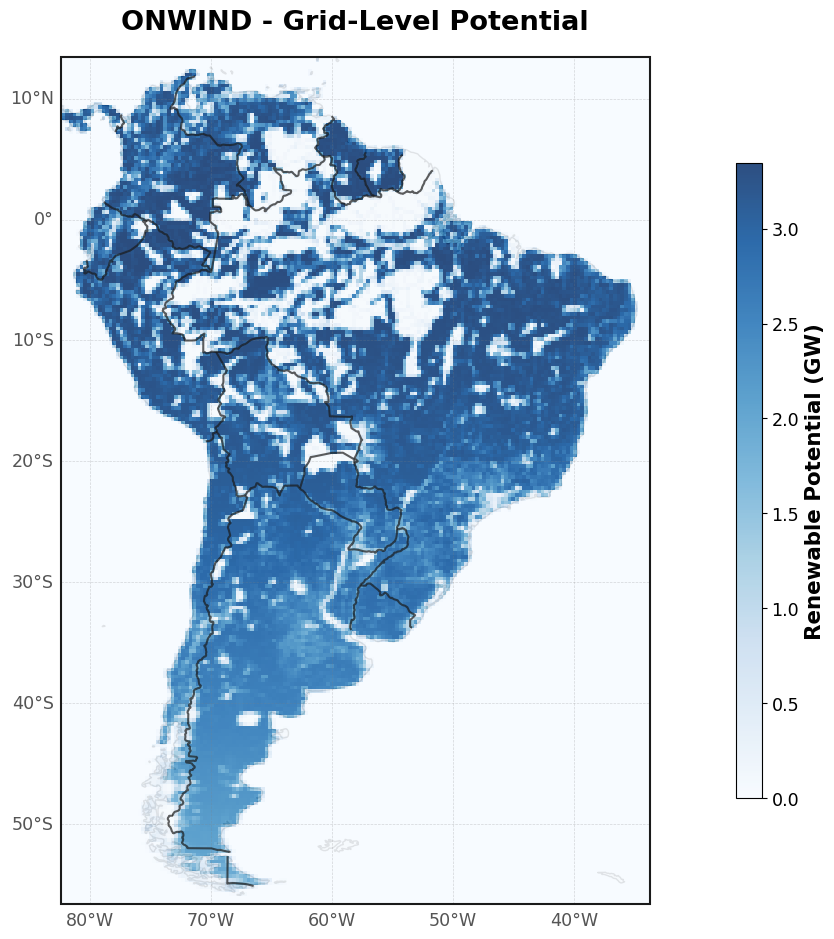

In [17]:
# ===== SECTION 10.1: Usage Examples - Visualization =====
"""
Examples of the two complementary plotting approaches for aggregated data.

Plot each technology separately to compare grid-level raster vs discrete bus regions.
"""

# ===== Plotting for Onwind Technology =====

# Onwind: Grid-level potential raster
fig, ax = plot_grid_potentials(
    profiles_ds,
    region=["AR", "BO", "BR", "CL", "CO", "EC", "GY", "PY", "PE", "SR", "UY", "VE"],
    technology="onwind",
    cmap="Blues",
    gridlabels=True,
    filename=None,
)
plt.show()

c:\Users\JanLeopoldTautorus\Repos\shift\.pixi\envs\dev\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
2026-04-16 12:33:37,558 - __main__ - INFO - Loading geometries for onwind (sequential processing)...
Processing onwind regions: 100%|██████████| 8217/8217 [00:15<00:00, 514.66it/s] 
2026-04-16 12:33:53,530 - __main__ - INFO - Plotting 6226 bus regions for onwind
2026-04-16 12:33:53,531 - __main__ - INFO -   Capacity density range: 0.000 - 4.122 MW/km²
C:\Users\JanLeopoldTautorus\AppData\Local\Temp\ipykernel_31552\212557232.py:221: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap(cmap)(norm(density))


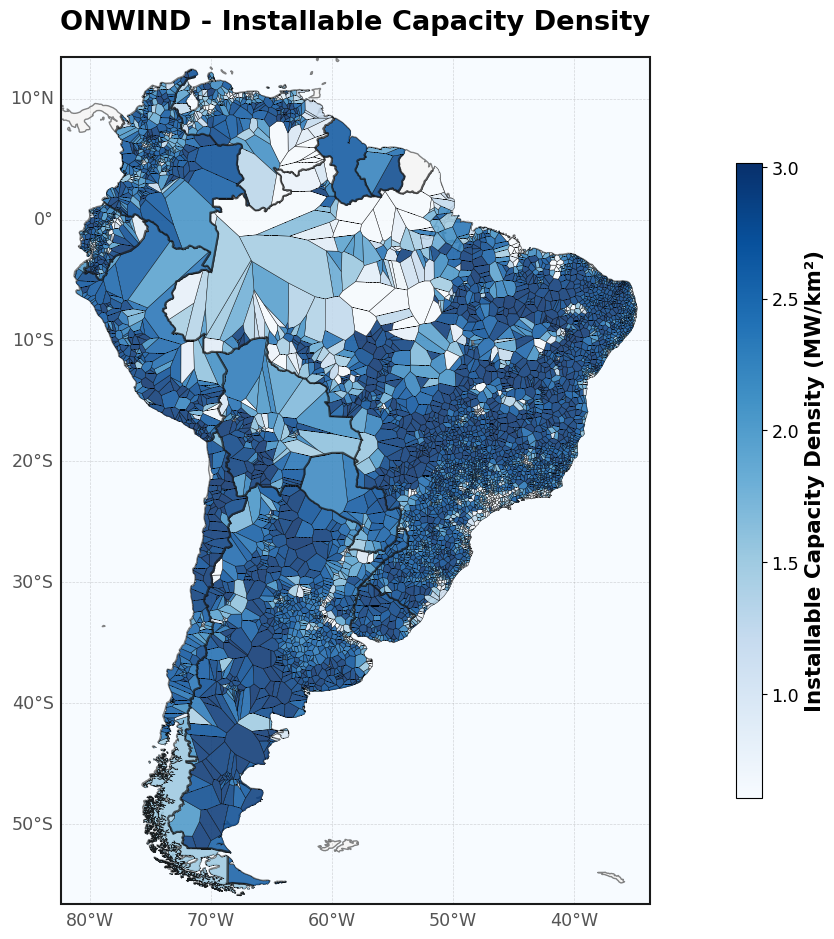

In [14]:
# Onwind: Bus regions colored by capacity density
fig, ax = plot_bus_potential_density(
    profiles_ds,
    region=["AR", "BO", "BR", "CL", "CO", "EC", "GY", "PY", "PE", "SR", "UY", "VE"],
    technology="onwind",
    cmap="Blues",
    gridlabels=True,
    filename=None,
)
plt.show()

c:\Users\JanLeopoldTautorus\Repos\shift\.pixi\envs\dev\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Users\JanLeopoldTautorus\Repos\shift\.pixi\envs\dev\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


(<Figure size 1400x1100 with 2 Axes>,
 <GeoAxes: title={'center': 'SOLAR - Grid-Level Potential'}, xlabel='Longitude (°E)', ylabel='Latitude (°N)'>)

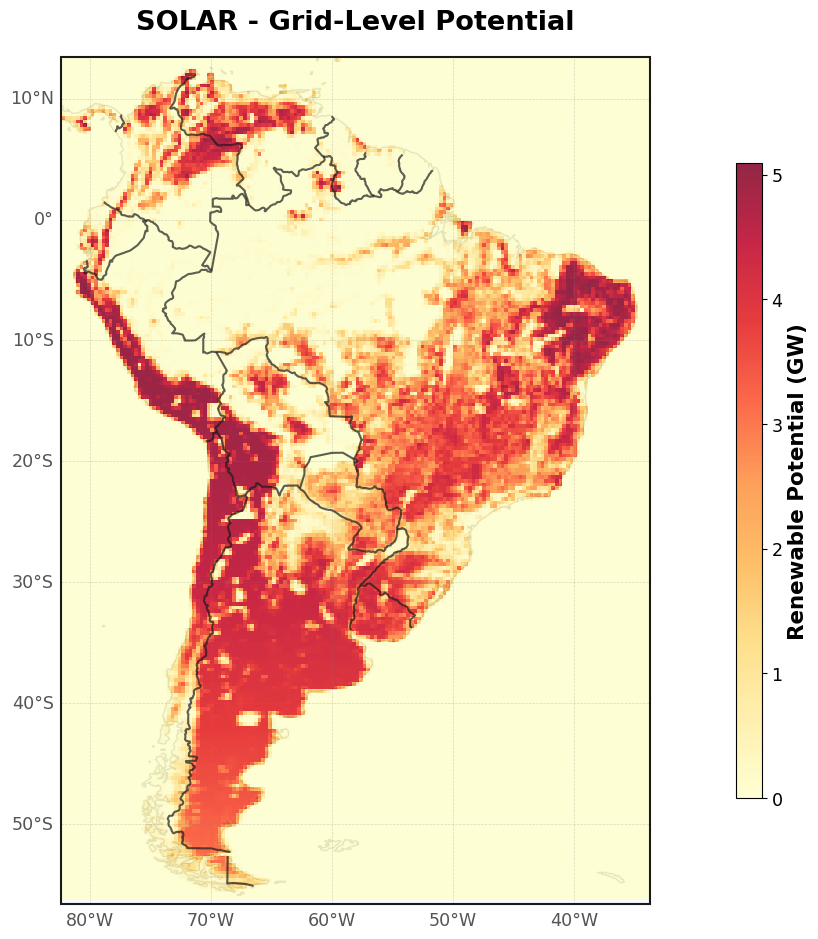

In [18]:
plot_grid_potentials(
    profiles_ds,
    region=["AR", "BO", "BR", "CL", "CO", "EC", "GY", "PY", "PE", "SR", "UY", "VE"],
    technology="solar",
    cmap="YlOrRd",
    gridlabels=True,
    filename=None,
)